In [32]:
import demes
import h2py
import numpy as np
import matplotlib.pyplot as plt
import msprime

In [2]:
b = demes.Builder()
b.add_deme("pop0", epochs=[{"start_size": 1e4, "end_time": 0}])
b.add_deme("pop1", start_time=1e4, ancestors=["pop0"],
           epochs=[{"start_size": 1e5, "end_time": 0}])
g = b.resolve()
demog = msprime.Demography.from_demes(g)
ts = msprime.sim_mutations(
    msprime.sim_ancestry(
        samples={"pop0": 1, "pop1": 1},
        demography=demog,
        sequence_length=10000000,
        recombination_rate=1e-8,
    ),
    rate=1e-8,
    model="binary"
)

In [3]:
r_bins = np.logspace(-6, -2, 17)
coords = np.arange(10000000) * 1e-8
model = h2py.H2stats.from_demes(
    g,
    r_bins=r_bins,
    u=1e-8,
    sampled_demes=["pop0", "pop1"],
    phased=True,
)
print(model[-1])

[0.0004     0.0006     0.00057557]


In [4]:
haplotypes = np.array([[b if b != "N" else "0" for b in seq]
              for seq in ts.as_fasta(wrap_width=0).split("\n")[1::2]], dtype=np.float64).T
print(haplotypes[0])

[0. 0. 0. 0.]


In [5]:
is_variant = np.where(np.sum(haplotypes, axis=1) > 0)[0]
hap_matrix = h2py.HaplotypeMatrix(
    haplotypes[is_variant],
    is_variant,
    {"pop0": [0], "pop1": [1]}
)
hap_sums = h2py.parsing.compute_h2_stats(
    haplotype_matrix=hap_matrix,
    interval=[0, 10000000],
    r_bins=r_bins,
    r=1e-8,
)
means = h2py.parsing.get_means_across_regions({0: hap_sums})

[26-07-17 10:47:07] Preparing data ...
[26-07-17 10:47:07] Prepared HaplotypeMatrix (10364 sites, 2 samples, 2 pops)
[26-07-17 10:47:07] Loaded map coordinates (2.7e-06 to 0.09998 M)
[26-07-17 10:47:07] Computing statistics ...
[26-07-17 10:47:07] Computed statistics.
[26-07-17 10:47:07] Computing denominators ...
[26-07-17 10:47:11] Computed denominators.
[26-07-17 10:47:11]     Done!


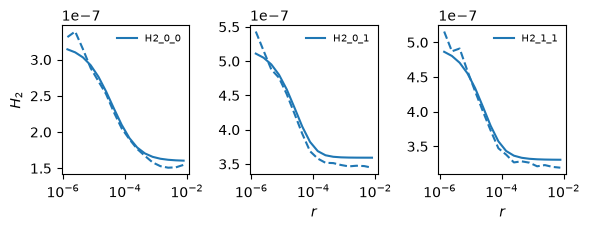

[0.0003946 0.0005915 0.0005704] [0.0004     0.0006     0.00057557]


In [7]:
h2py.plotting.plot_h2_curves_comp(
    model,
    means,
    None,
    stats=["H2_0_0", "H2_0_1", "H2_1_1"],
    r_bins=r_bins,
    plot_errs=False,
    fig_size=(6, 2.4)
)
print(means[-1], model[-1])

In [12]:
def generate_reads(haplotypes, depth, p_err):
    seq_len = len(haplotypes)
    n_samples = int(haplotypes.shape[1] / 2)
    reads = np.zeros_like(haplotypes, dtype=np.int64)

    for idx in range(n_samples):
        genotypes = np.sum(haplotypes[:, 2 * idx:2 * (idx + 1)], axis=1)
        depth = np.random.poisson(depth, size=seq_len)
        f_alt = genotypes / 2
        p_alt = f_alt + (1 - 2 * f_alt) * p_err
        n_alt = np.random.binomial(depth, p_alt)
        n_ref = depth - n_alt
        reads[:, 2 * idx] = n_ref
        reads[:, 2 * idx + 1] = n_alt

    sites = np.where(np.sum(reads, axis=1) > 0)[0]
    reads = reads[sites]

    return sites, reads

In [31]:
def div_from_reads(reads1, reads2):
    # Calculate divergence from reads
    depth1 = np.sum(reads1, axis=1)
    depth2 = np.sum(reads2, axis=1)
    idx = np.where((depth1 > 0) & (depth2 > 0))[0]
    f_alt1 = reads1[idx][:, 1] / depth1[idx]
    f_ref1 = 1 - f_alt1
    f_alt2 = reads2[idx][:, 1] / depth2[idx]
    f_ref2 = 1 - f_alt2
    return f_ref1 * f_alt2 + f_alt1 * f_ref2


sites, reads = generate_reads(haplotypes, 5, 1e-3)
site_div = div_from_reads(reads[:, :2], reads[:, 2:])
print(np.sum(site_div) / len(site_div))

0.0025857419814419346


In [36]:
err_rates = [1e-5, 1e-4, 1e-3]
depths = [1, 2, 4, 5, 10, 15, 20, 30,]
divs = []
for p_err in err_rates:
    _divs = []
    for depth in depths:
        sites, reads = generate_reads(haplotypes, depth, p_err)
        site_div = div_from_reads(reads[:, :2], reads[:, 2:])
        div = np.sum(site_div) / len(site_div)
        _divs.append(div)
    divs.append(_divs)

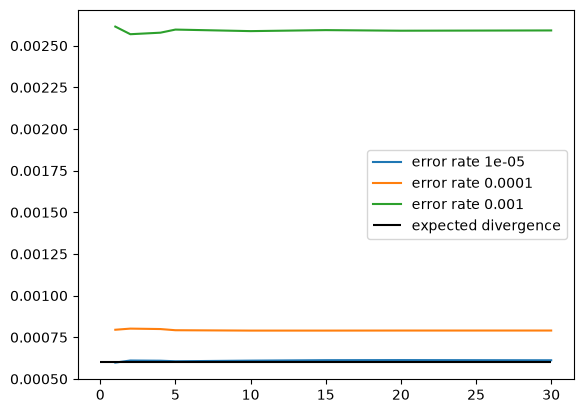

In [37]:
for i, p in enumerate(err_rates):
    plt.plot(depths, divs[i], label=f"error rate {p}")
plt.hlines(model[-1][1], 0, 30, color="black", label="expected divergence")
plt.legend()